# Pushshift Neural Baseline: GloVe + BiLSTM

This notebook implements the GloVe + BiLSTM neural baseline for the Pushshift Reddit pipeline under the unified project structure.

It is designed to:
- load the processed Reddit dataset from `Dataset/pushshift/`
- align paths with the shared `Code/artifacts/pushshift/` layout
- train a three-class GloVe + BiLSTM neural baseline
- save reusable experiment artifacts for later comparison with TF-IDF and BERT models
- export evaluation outputs that can support later thesis writing

## 0. Verify required packages

This section checks the main dependencies used in the LSTM experiment.
It helps reduce environment-related issues before training starts.

In [1]:
import importlib
import subprocess
import sys

def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} already installed")
    except ImportError:
        print(f"⬇️ Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("torch", "torch"),
    ("scikit-learn", "sklearn"),
    ("keras-preprocessing", "keras_preprocessing"),
    ("joblib", "joblib"),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)

print("Python executable:", sys.executable)

✅ numpy already installed
✅ pandas already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ torch already installed
✅ scikit-learn already installed
✅ keras-preprocessing already installed
✅ joblib already installed
Python executable: d:\Anaconda\envs\happiness-nlp\python.exe


## 1. Setup and unified paths

The notebook resolves paths relative to the current VSCode notebook location.
Outputs are saved under the same `artifacts/pushshift` structure used by the baseline model.

In [2]:
# === 1) Setup & Unified Paths ===
import json
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Compatibility fix for NumPy 2.0+
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

from keras_preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROJECT_ROOT = CODE_DIR.parent

DATASET_DIR = PROJECT_ROOT / "Dataset" / "pushshift"
ARTIFACT_ROOT = CODE_DIR / "artifacts"
DATASET_NAME = "pushshift"
DATASET_ARTIFACT_DIR = ARTIFACT_ROOT / DATASET_NAME

SPLIT_DIR = DATASET_ARTIFACT_DIR / "splits"
PRED_DIR = DATASET_ARTIFACT_DIR / "predictions"
MODEL_DIR = DATASET_ARTIFACT_DIR / "models"
CONFIG_DIR = DATASET_ARTIFACT_DIR / "config"
FIG_DIR = DATASET_ARTIFACT_DIR / "figures"
RESOURCE_DIR = DATASET_ARTIFACT_DIR / "resources"
RESULT_DIR = DATASET_ARTIFACT_DIR / "results"

for folder in [ARTIFACT_ROOT, DATASET_ARTIFACT_DIR, SPLIT_DIR, PRED_DIR, MODEL_DIR, CONFIG_DIR, FIG_DIR, RESOURCE_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATASET_DIR / "reddit_vader_dataset.csv"
TRAIN_PATH = SPLIT_DIR / "train_60.csv"
VAL_PATH   = SPLIT_DIR / "val_10.csv"
TEST_PATH  = SPLIT_DIR / "test_30.csv"

GLOVE_PATH = CODE_DIR / "glove" / "glove.6B.300d.txt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CSV_PATH:", CSV_PATH)
print("GLOVE_PATH:", GLOVE_PATH)

RANDOM_STATE = 42
MAX_VOCAB = 50_000
MAX_LEN = 80
EMBED_DIM = 300
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS = 6
LR = 1e-3
DROPOUT = 0.5
EMBED_DROPOUT = 0.2
EARLY_STOPPING_PATIENCE = 2

LABEL_MAP = {0: "Negative", 1: "Neutral", 2: "Positive"}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

sns.set_theme(style="whitegrid")

Using device: cuda
CSV_PATH: e:\桌面\Graduation_Thesis\Dataset\pushshift\reddit_vader_dataset.csv
GLOVE_PATH: e:\桌面\Graduation_Thesis\Code\glove\glove.6B.300d.txt


## 2. Load fixed dataset splits

If the shared train/validation/test CSV files already exist, they are reused.
Otherwise, the notebook creates fixed 60/10/30 stratified splits from the Reddit dataset and saves them.

In [3]:
from sklearn.model_selection import train_test_split

if TRAIN_PATH.exists() and VAL_PATH.exists() and TEST_PATH.exists():
    train_df = pd.read_csv(TRAIN_PATH)
    val_df   = pd.read_csv(VAL_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    print("Loaded existing fixed splits.")
else:
    if not CSV_PATH.exists():
        raise FileNotFoundError(f"Missing dataset file: {CSV_PATH}")

    df = pd.read_csv(CSV_PATH)
    df = df.dropna(subset=["text", "label"]).copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

    train_df, temp_df = train_test_split(
        df,
        test_size=0.4,
        random_state=RANDOM_STATE,
        stratify=df["label"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.75,
        random_state=RANDOM_STATE,
        stratify=temp_df["label"]
    )

    train_df.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    val_df.to_csv(VAL_PATH, index=False, encoding="utf-8")
    test_df.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Created and saved fixed splits.")

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

Loaded existing fixed splits.
Train / Val / Test sizes: 16931 2822 8466


In [4]:
for split_name, split_df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():
    print(f"\n{split_name} label distribution:")
    print(split_df["label"].value_counts().sort_index())


Train label distribution:
label
0.0    4485
1.0    4207
2.0    8239
Name: count, dtype: int64

Validation label distribution:
label
0.0     748
1.0     701
2.0    1373
Name: count, dtype: int64

Test label distribution:
label
0.0    2243
1.0    2103
2.0    4120
Name: count, dtype: int64


## 3. Text preparation

A light cleaning step is applied before tokenisation.
The goal is to keep the Reddit text usable for sequence modelling without over-processing emotional signals.

In [5]:
import re

def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

for split_df in [train_df, val_df, test_df]:
    split_df["text_clean"] = split_df["text"].astype(str).apply(basic_clean)

train_df[["text", "text_clean", "label"]].head()

,text,text_clean,label
0,Lol Thats good. So what happened when you got ...,Lol Thats good. So what happened when you got ...,2.0
1,I worked at a summer camp in Texas once. After...,I worked at a summer camp in Texas once. After...,2.0
2,Just a strange way to refer to a best friend. ...,Just a strange way to refer to a best friend. ...,2.0
3,Armageddon. I've seen it more times than I ca...,Armageddon. I've seen it more times than I can...,1.0
4,I know that but it triggered me,I know that but it triggered me,1.0


## 4. Tokenisation and padding

The training texts are used to build the tokenizer vocabulary.
All sequences are then padded to a fixed length for mini-batch training.

In [6]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text_clean"].astype(str).tolist())

train_seq = tokenizer.texts_to_sequences(train_df["text_clean"].astype(str).tolist())
val_seq   = tokenizer.texts_to_sequences(val_df["text_clean"].astype(str).tolist())
test_seq  = tokenizer.texts_to_sequences(test_df["text_clean"].astype(str).tolist())

X_train = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_df["label"].astype(int).to_numpy()
y_val   = val_df["label"].astype(int).to_numpy()
y_test  = test_df["label"].astype(int).to_numpy()

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Train padded shape:", X_train.shape)
print("Validation padded shape:", X_val.shape)
print("Test padded shape:", X_test.shape)

Vocabulary size used: 23415
Train padded shape: (16931, 80)
Validation padded shape: (2822, 80)
Test padded shape: (8466, 80)


## 5. Load pretrained GloVe embeddings

This step reads the GloVe vectors from the shared `Code/glove` folder.
If the file is missing, the notebook stops early so the issue is explicit.

In [7]:
if not GLOVE_PATH.exists():
    raise FileNotFoundError(
        f"Missing GloVe file at: {GLOVE_PATH}\n"
        "Please place glove.6B.300d.txt in the Code/glove folder."
    )

embeddings_index = {}
with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        values = line.rstrip().split(" ")
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Loaded GloVe vectors:", len(embeddings_index))

Loaded GloVe vectors: 400000


## 6. Build the embedding matrix

The tokenizer vocabulary is aligned with the GloVe vectors.
Words not found in GloVe receive small random initial values so they can still be trained.

In [8]:
rng = np.random.default_rng(RANDOM_STATE)
embedding_matrix = rng.normal(0, 0.05, size=(vocab_size, EMBED_DIM)).astype("float32")

hits = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        hits += 1

coverage = hits / max(1, vocab_size - 1)
print(f"GloVe hits: {hits}")
print(f"Coverage: {coverage:.2%}")

GloVe hits: 18923
Coverage: 80.82%


## 7. Build datasets and dataloaders

The processed arrays are wrapped in PyTorch datasets and dataloaders.
This keeps the training loop consistent with the Sentiment140 neural baseline.

In [9]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


## 8. Define the BiLSTM model

A bidirectional LSTM is used as the neural baseline.
Compared with the TF-IDF baseline, this model can capture word order and contextual dependencies more directly.

In [10]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix: np.ndarray, hidden_dim: int = 128, dropout: float = 0.5, embed_dropout: float = 0.2, num_classes: int = 3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = True

        self.embedding_dropout = nn.Dropout(embed_dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)
        _, (h_n, _) = self.lstm(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    embed_dropout=EMBED_DROPOUT,
    num_classes=3,
).to(device)

class_counts = np.bincount(y_train, minlength=3)
class_weights = len(y_train) / (3 * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print("Class weights:", class_weights.detach().cpu().numpy())

BiLSTMClassifier(
  (embedding): Embedding(23415, 300, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)
Class weights: [1.2583426  1.3414943  0.68499416]


## 9. Train the model

The model is trained with validation monitoring and early stopping.

Validation **macro-F1** is used to select the best checkpoint, while validation loss is recorded as an auxiliary optimization signal. This is more appropriate for the three-class Pushshift task, where balanced performance across classes is important for later happiness index construction.

The best validation checkpoint is saved for later evaluation and comparison.

In [11]:
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item()
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    avg_loss = total_loss / max(1, len(loader))
    probs = np.concatenate(all_probs)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    return avg_loss, probs, preds, labels


history = []
best_val_macro_f1 = -float("inf")
best_path = MODEL_DIR / "pushshift_bilstm_3class.pt"
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / max(1, len(train_loader))
    val_loss, val_probs, val_preds, val_labels = evaluate_loader(model, val_loader, criterion)

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_f1,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_macro_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print(
            f"  Saved best checkpoint "
            f"(best val_macro_f1={best_val_macro_f1:.4f}) -> {best_path}"
        )
    else:
        patience_counter += 1
        print(
            f"  No macro-F1 improvement. "
            f"Early stopping counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}"
        )
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("  Early stopping triggered.")
            break

Epoch 01 | train_loss=0.7988 | val_loss=0.6098 | val_acc=0.7495 | val_macro_f1=0.7337
  Saved best checkpoint (best val_macro_f1=0.7337) -> e:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bilstm_3class.pt
Epoch 02 | train_loss=0.4980 | val_loss=0.4758 | val_acc=0.8193 | val_macro_f1=0.8110
  Saved best checkpoint (best val_macro_f1=0.8110) -> e:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bilstm_3class.pt
Epoch 03 | train_loss=0.3471 | val_loss=0.4553 | val_acc=0.8278 | val_macro_f1=0.8245
  Saved best checkpoint (best val_macro_f1=0.8245) -> e:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bilstm_3class.pt
Epoch 04 | train_loss=0.2599 | val_loss=0.5126 | val_acc=0.8384 | val_macro_f1=0.8308
  Saved best checkpoint (best val_macro_f1=0.8308) -> e:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bilstm_3class.pt
Epoch 05 | train_loss=0.1977 | val_loss=0.5046 | val_acc=0.8306 | val_macro_f1=0.8280
  No macro-F1 improvem

## 10. Save the learning curve

The training history is exported as both a CSV file and a figure.
This makes it easier to compare optimisation behaviour across the baseline, LSTM, and BERT models.

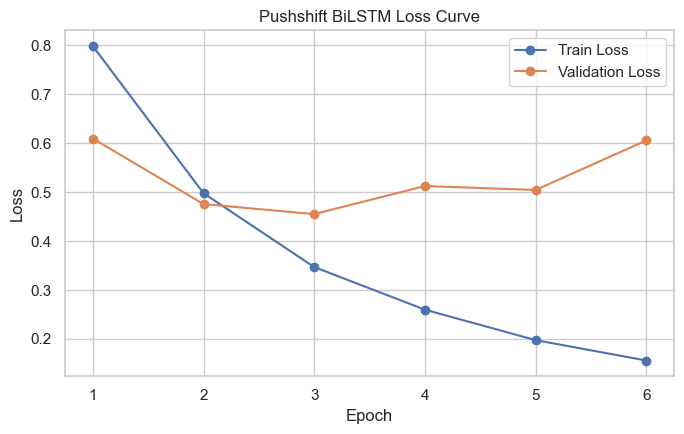

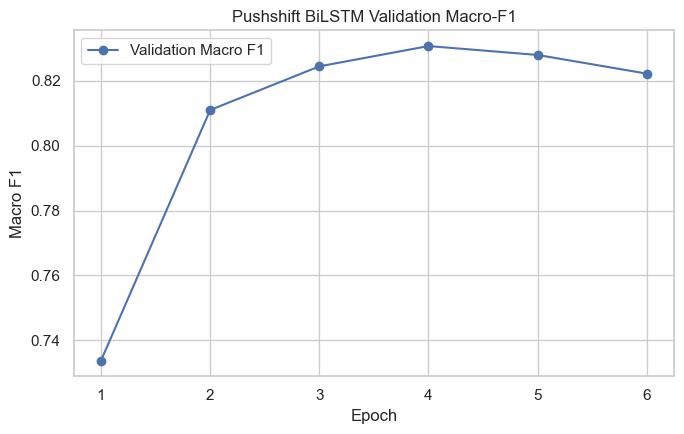

Saved training history CSV: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\resources\lstm_training_history.csv
Saved loss curve: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\lstm_loss_curve.png
Saved macro-F1 curve: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\lstm_macro_f1_curve.png


In [18]:
history_df = pd.DataFrame(history)
history_csv_path = RESOURCE_DIR / "lstm_training_history.csv"
history_df.to_csv(history_csv_path, index=False, encoding="utf-8")

# === Loss curve ===
plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pushshift BiLSTM Loss Curve")
plt.legend()
plt.tight_layout()

loss_curve_path = FIG_DIR / "lstm_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# === Validation Macro-F1 curve ===
plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Pushshift BiLSTM Validation Macro-F1")
plt.legend()
plt.tight_layout()

f1_curve_path = FIG_DIR / "lstm_macro_f1_curve.png"
plt.savefig(f1_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved training history CSV:", history_csv_path.resolve())
print("Saved loss curve:", loss_curve_path.resolve())
print("Saved macro-F1 curve:", f1_curve_path.resolve())

## 11. Evaluate on the test set

The best validation checkpoint is reloaded and evaluated on the held-out test set.
Standard metrics and a confusion matrix are generated for reporting in the dissertation.

In [13]:
model.load_state_dict(torch.load(best_path, map_location=device))

test_loss, test_probs, test_preds, test_labels = evaluate_loader(model, test_loader, criterion)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(accuracy_score(test_labels, test_preds), 4))
print("Test macro F1:", round(f1_score(test_labels, test_preds, average="macro"), 4))

print("\nClassification report:")
print(classification_report(test_labels, test_preds, digits=4, target_names=[LABEL_MAP[i] for i in range(3)]))

C:\Users\seventh720\AppData\Local\Temp\ipykernel_20652\2494648165.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_locatio

Test loss: 0.5305
Test accuracy: 0.8376
Test macro F1: 0.8305

Classification report:
              precision    recall  f1-score   support

    Negative     0.7608    0.7303    0.7452      2243
     Neutral     0.8818    0.8835    0.8827      2103
    Positive     0.8547    0.8726    0.8636      4120

    accuracy                         0.8376      8466
   macro avg     0.8325    0.8288    0.8305      8466
weighted avg     0.8366    0.8376    0.8370      8466



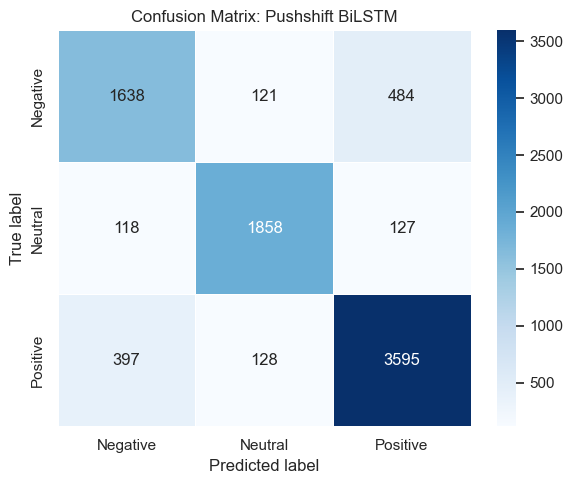

Saved confusion matrix figure: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\lstm_confusion_matrix.png


In [14]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=[LABEL_MAP[i] for i in range(3)],
    yticklabels=[LABEL_MAP[i] for i in range(3)],
    linewidths=0.5,
    linecolor="white",
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Pushshift BiLSTM")
plt.tight_layout()

cm_path = FIG_DIR / "lstm_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure:", cm_path.resolve())

## 12. Construct a temporal happiness index

The test-set predictions are converted into both discrete and probability-based happiness scores.
These scores are then aggregated overall, by time window, and by subreddit-time window for later comparison.

In [15]:

# Build prediction table first so the happiness-index outputs can reuse it.
pred_df = test_df.copy()
pred_df["text_clean"] = test_df["text_clean"].values
pred_df["y_true"] = test_labels.astype(int)
pred_df["pred_label"] = test_preds.astype(int)
pred_df["prob_negative"] = test_probs[:, 0].astype(float)
pred_df["prob_neutral"] = test_probs[:, 1].astype(float)
pred_df["prob_positive"] = test_probs[:, 2].astype(float)
pred_df["pred_label_name"] = pred_df["pred_label"].map(LABEL_MAP)
pred_df["true_label_name"] = pred_df["y_true"].map(LABEL_MAP)

label_to_score = {0: -1, 1: 0, 2: 1}

hi_df = pred_df.copy()

if "created_utc" not in hi_df.columns:
    raise ValueError("`created_utc` is required to construct the temporal happiness index for Pushshift.")

if pd.api.types.is_numeric_dtype(hi_df["created_utc"]):
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], unit="s", utc=True, errors="coerce")
else:
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], utc=True, errors="coerce")

hi_df = hi_df.dropna(subset=["created_dt"]).copy()
hi_df = hi_df.sort_values("created_dt").reset_index(drop=True)

if hi_df.empty:
    raise ValueError("No valid timestamps were available after parsing `created_utc`.")

hi_df["score_label_3class"] = hi_df["pred_label"].map(label_to_score)
hi_df["score_prob_continuous"] = hi_df["prob_positive"] - hi_df["prob_negative"]

time_span_days = (hi_df["created_dt"].max() - hi_df["created_dt"].min()).days
created_dt_naive = hi_df["created_dt"].dt.tz_localize(None)

if time_span_days >= 90:
    temporal_window = "month"
    hi_df["time_window"] = created_dt_naive.dt.to_period("M").astype(str)
elif time_span_days >= 28:
    temporal_window = "week"
    hi_df["time_window"] = created_dt_naive.dt.to_period("W-MON").astype(str)
else:
    temporal_window = "day"
    hi_df["time_window"] = created_dt_naive.dt.strftime("%Y-%m-%d")

def ratio(series, value):
    return float((series == value).mean())

def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce")
    return float(s.mean()) if s.notna().any() else np.nan

overall_summary = {
    "dataset": "pushshift",
    "model": "glove_bilstm",
    "index_variant": "overall_temporal_ready",
    "sample_size": int(len(hi_df)),
    "time_span_days": int(time_span_days),
    "temporal_window": temporal_window,
    "n_time_windows": int(hi_df["time_window"].nunique()),
    "negative_ratio": ratio(hi_df["pred_label"], 0),
    "neutral_ratio": ratio(hi_df["pred_label"], 1),
    "positive_ratio": ratio(hi_df["pred_label"], 2),
    "mean_prob_negative": safe_mean(hi_df["prob_negative"]),
    "mean_prob_neutral": safe_mean(hi_df["prob_neutral"]),
    "mean_prob_positive": safe_mean(hi_df["prob_positive"]),
    "hi_label_raw": safe_mean(hi_df["score_label_3class"]),
    "hi_label_100": float(50 * (safe_mean(hi_df["score_label_3class"]) + 1)),
    "hi_prob_raw": safe_mean(hi_df["score_prob_continuous"]),
    "hi_prob_100": float(50 * (safe_mean(hi_df["score_prob_continuous"]) + 1)),
}

temporal_rows = []
for time_window, g in hi_df.groupby("time_window", sort=False):
    window_start_dt = g["created_dt"].min()
    row = {
        "time_window": time_window,
        "time_window_start": window_start_dt.strftime("%Y-%m-%d"),
        "time_window_start_utc": window_start_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "sample_size": int(len(g)),
        "negative_ratio": ratio(g["pred_label"], 0),
        "neutral_ratio": ratio(g["pred_label"], 1),
        "positive_ratio": ratio(g["pred_label"], 2),
        "mean_prob_negative": safe_mean(g["prob_negative"]),
        "mean_prob_neutral": safe_mean(g["prob_neutral"]),
        "mean_prob_positive": safe_mean(g["prob_positive"]),
        "hi_label_raw": safe_mean(g["score_label_3class"]),
        "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
        "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
        "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)),
    }
    temporal_rows.append(row)

temporal_hi_df = pd.DataFrame(temporal_rows).sort_values("time_window_start").reset_index(drop=True)

subreddit_temporal_hi_df = pd.DataFrame()
if "subreddit" in hi_df.columns:
    subreddit_rows = []
    for (subreddit, time_window), g in hi_df.groupby(["subreddit", "time_window"], sort=False):
        window_start_dt = g["created_dt"].min()
        row = {
            "subreddit": subreddit,
            "time_window": time_window,
            "time_window_start": window_start_dt.strftime("%Y-%m-%d"),
            "time_window_start_utc": window_start_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "sample_size": int(len(g)),
            "negative_ratio": ratio(g["pred_label"], 0),
            "neutral_ratio": ratio(g["pred_label"], 1),
            "positive_ratio": ratio(g["pred_label"], 2),
            "hi_label_raw": safe_mean(g["score_label_3class"]),
            "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
            "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
            "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)),
        }
        subreddit_rows.append(row)

    subreddit_temporal_hi_df = (
        pd.DataFrame(subreddit_rows)
        .sort_values(["subreddit", "time_window_start"])
        .reset_index(drop=True)
    )

overall_summary_df = pd.DataFrame([overall_summary])

print("Selected temporal window:", temporal_window)
print("Time span (days):", time_span_days)
print("Number of windows:", hi_df["time_window"].nunique())

print("\nOverall happiness index summary:")
display(overall_summary_df)

print("\nTemporal happiness index preview:")
display(temporal_hi_df.head())

if not subreddit_temporal_hi_df.empty:
    print("\nSubreddit-level temporal happiness index preview:")
    display(subreddit_temporal_hi_df.head())


Selected temporal window: month
Time span (days): 335
Number of windows: 12

Overall happiness index summary:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,glove_bilstm,overall_temporal_ready,8466,335,month,12,0.254311,0.248878,0.496811,0.246963,0.270499,0.482538,0.242499,62.12497,0.235575,61.778754



Temporal happiness index preview:


,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.251445,0.218208,0.530347,0.239960,0.239906,0.520134,0.278902,63.945087,0.280174,64.008678
1,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.257511,0.220315,0.522175,0.246911,0.245113,0.507977,0.264664,63.233190,0.261066,63.053317
2,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.257143,0.247619,0.495238,0.255573,0.270634,0.473793,0.238095,61.904762,0.218220,60.911020
3,2022-04,2022-04-01,2022-04-01T00:00:00Z,684,0.255848,0.277778,0.466374,0.247108,0.294710,0.458183,0.210526,60.526316,0.211075,60.553762
4,2022-05,2022-05-01,2022-05-01T00:00:00Z,695,0.279137,0.258993,0.461871,0.269090,0.283795,0.447114,0.182734,59.136691,0.178024,58.901190



Subreddit-level temporal happiness index preview:


,subreddit,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,AskReddit,2022-01,2022-01-01,2022-01-01T00:00:00Z,221,0.262443,0.398190,0.339367,0.076923,53.846154,0.078871,53.943533
1,AskReddit,2022-02,2022-02-01,2022-02-01T00:00:00Z,241,0.278008,0.373444,0.348548,0.070539,53.526971,0.075593,53.779634
2,AskReddit,2022-03,2022-03-01,2022-03-01T00:00:00Z,229,0.192140,0.358079,0.449782,0.257642,62.882096,0.231256,61.562817
3,AskReddit,2022-04,2022-04-01,2022-04-01T00:00:00Z,222,0.229730,0.468468,0.301802,0.072072,53.603604,0.083472,54.173620
4,AskReddit,2022-05,2022-05-01,2022-05-01T00:00:00Z,221,0.294118,0.352941,0.352941,0.058824,52.941176,0.065410,53.270513


## 13. Export experiment artifacts

All reusable outputs are saved to the unified artifact structure.
This includes the trained model, tokenizer, prediction files, and temporal happiness-index summaries for later comparison.

In [16]:
best_recorded_val_loss = min(item["val_loss"] for item in history) if history else None

model_config = {
    "model_name": "glove_bilstm_3class",
    "dataset": "pushshift",
    "random_state": RANDOM_STATE,
    "max_vocab": MAX_VOCAB,
    "max_len": MAX_LEN,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "dropout": DROPOUT,
    "embed_dropout": EMBED_DROPOUT,
    "best_checkpoint_metric": "val_macro_f1",
    "best_val_macro_f1": float(best_val_macro_f1),
    "best_recorded_val_loss": float(best_recorded_val_loss) if best_recorded_val_loss is not None else None,
    "class_weights": class_weights.detach().cpu().numpy().tolist(),
}

model_config_path = CONFIG_DIR / "lstm_model_config.json"
with open(model_config_path, "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

tokenizer_path = RESOURCE_DIR / "lstm_tokenizer.joblib"
joblib.dump(tokenizer, tokenizer_path)

pred_df["score_label_3class"] = pred_df["pred_label"].map(label_to_score)
pred_df["score_prob_continuous"] = pred_df["prob_positive"] - pred_df["prob_negative"]

pred_path = PRED_DIR / "pred_test_lstm_3class.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8")

overall_summary_path = RESULT_DIR / "lstm_happiness_index_overall.json"
with open(overall_summary_path, "w", encoding="utf-8") as f:
    json.dump(overall_summary, f, ensure_ascii=False, indent=2)

overall_summary_csv_path = RESULT_DIR / "lstm_happiness_index_summary.csv"
overall_summary_df.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")

temporal_hi_path = RESULT_DIR / "lstm_temporal_happiness_index.csv"
temporal_hi_df.to_csv(temporal_hi_path, index=False, encoding="utf-8")

subreddit_temporal_hi_path = RESULT_DIR / "lstm_subreddit_temporal_happiness_index.csv"
if not subreddit_temporal_hi_df.empty:
    subreddit_temporal_hi_df.to_csv(subreddit_temporal_hi_path, index=False, encoding="utf-8")

print("Saved best model:", best_path.resolve())
print("Saved tokenizer:", tokenizer_path.resolve())
print("Saved model config:", model_config_path.resolve())
print("Saved predictions:", pred_path.resolve())
print("Saved overall happiness summary:", overall_summary_path.resolve())
print("Saved happiness summary CSV:", overall_summary_csv_path.resolve())
print("Saved temporal happiness index:", temporal_hi_path.resolve())
if not subreddit_temporal_hi_df.empty:
    print("Saved subreddit temporal happiness index:", subreddit_temporal_hi_path.resolve())

Saved best model: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bilstm_3class.pt
Saved tokenizer: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\resources\lstm_tokenizer.joblib
Saved model config: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\config\lstm_model_config.json
Saved predictions: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\predictions\pred_test_lstm_3class.csv
Saved overall happiness summary: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\lstm_happiness_index_overall.json
Saved happiness summary CSV: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\lstm_happiness_index_summary.csv
Saved temporal happiness index: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\lstm_temporal_happiness_index.csv
Saved subreddit temporal happiness index: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\lstm_subreddit_temporal_happiness_index.csv


## 14. Optional error analysis

Misclassified examples can be inspected qualitatively to understand where the neural baseline still struggles.
This is especially useful for mixed emotion, sarcasm, or context-heavy Reddit comments.

In [17]:
error_df = pred_df[pred_df["y_true"] != pred_df["pred_label"]].reset_index(drop=True)
print("Number of misclassified examples:", len(error_df))
error_df[["text", "true_label_name", "pred_label_name", "prob_negative", "prob_neutral", "prob_positive"]].head(20)

Number of misclassified examples: 1375


,text,true_label_name,pred_label_name,prob_negative,prob_neutral,prob_positive
0,A case full of guns next to the home improveme...,Positive,Neutral,0.021169,0.887643,0.091189
1,I feel like an alien in this society I live in...,Negative,Positive,0.010652,0.002878,0.986470
2,Value the time you have with your from here on...,Positive,Neutral,0.001027,0.992520,0.006453
3,Canes.\n\nOnly thing good is the sauce and bre...,Positive,Negative,0.787633,0.073334,0.139033
4,Not about my first love. You would think I wou...,Negative,Positive,0.424309,0.027632,0.548059
5,Whether or not these moral lessons can be impa...,Negative,Positive,0.018215,0.005495,0.976291
6,Elect more progressive Democrats.,Neutral,Positive,0.088600,0.299742,0.611658
7,I quit mine years ago. I didn't get better,Negative,Positive,0.040147,0.055850,0.904002
8,"So, the actual aesthetic Lucas has said he wan...",Negative,Positive,0.312177,0.112403,0.575420
9,Well I'm don't know for anyone else but for me...,Negative,Positive,0.334702,0.031704,0.633594
